# ML Phase 9: Model Comparison and Best Model Selection

## Objective

The purpose of this phase is to compare the regression models trained in Phase 8 and select the most suitable model for predicting Walmart weekly sales.

The models will be compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The final model will not be selected using only one metric. All three evaluation metrics will be considered before making the final decision.

In [21]:
# Importing the required libraries

from pathlib import Path
import pickle

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the Required Libraries

The following libraries are used in this phase:

- `Path` creates reliable file and folder paths.
- `pickle` loads and saves trained Python objects.
- `pandas` loads and analyses the model evaluation results.
- `matplotlib` and `seaborn` create model-comparison charts.

In [22]:
# Defining the project paths

current_path = Path.cwd()
project_root = current_path.parent

prepared_data_path = (
    project_root
    / "data"
    / "prepared"
)

models_path = (
    project_root
    / "models"
)

images_path = (
    project_root
    / "reports"
    / "images"
)

images_path.mkdir(
    parents=True,
    exist_ok=True,
)

print("Current folder:", current_path)
print("Project root:", project_root)
print("Prepared data folder:", prepared_data_path)
print("Models folder:", models_path)
print("Images folder:", images_path)

Current folder: c:\Users\Udoch\walmart-sales-regression\notebooks
Project root: c:\Users\Udoch\walmart-sales-regression
Prepared data folder: c:\Users\Udoch\walmart-sales-regression\data\prepared
Models folder: c:\Users\Udoch\walmart-sales-regression\models
Images folder: c:\Users\Udoch\walmart-sales-regression\reports\images


In [23]:
# Defining the input files

results_path = (
    prepared_data_path
    / "model_training_results.csv"
)

trained_models_path = (
    models_path
    / "trained_regression_models.pkl"
)

print("Results file:", results_path)
print("Results file exists:", results_path.exists())

print("Models file:", trained_models_path)
print("Models file exists:", trained_models_path.exists())

Results file: c:\Users\Udoch\walmart-sales-regression\data\prepared\model_training_results.csv
Results file exists: True
Models file: c:\Users\Udoch\walmart-sales-regression\models\trained_regression_models.pkl
Models file exists: True


In [24]:
# Validating the required files

if not results_path.exists():
    raise FileNotFoundError(
        f"Model results file not found at: {results_path}"
    )

if not trained_models_path.exists():
    raise FileNotFoundError(
        f"Trained models file not found at: {trained_models_path}"
    )

print("All Phase 8 files were found successfully.")

All Phase 8 files were found successfully.


## Validating the Phase 8 Files

Before comparing the models, the notebook confirms that the model evaluation results and trained-model file exist.

This prevents the notebook from continuing with missing inputs and producing misleading results.

In [25]:
# Loading the model evaluation results

results_df = pd.read_csv(
    results_path
)

results_df

,model,mae,rmse,r2_score
0,Linear Regression,69989.550167,101451.251870,0.963850
1,Decision Tree,138187.230107,197760.411629,0.862636
2,Random Forest,80398.992144,116209.227572,0.952567
3,Gradient Boosting,176368.383347,201032.573717,0.858052


From the Phase 8 results, the table is containing columns similar to it.

In [26]:
# Inspecting the results structure

print("Shape:", results_df.shape)
print()

print("Columns:")
print(results_df.columns.tolist())
print()

print("Data types:")
print(results_df.dtypes)

Shape: (4, 4)

Columns:
['model', 'mae', 'rmse', 'r2_score']

Data types:
model           str
mae         float64
rmse        float64
r2_score    float64
dtype: object


This represents:

- Four regression models.
- Four result columns.

In [27]:
# Formatting the results

formatted_results_df = results_df.copy()

formatted_results_df["mae"] = (
    formatted_results_df["mae"]
    .round(2)
)

formatted_results_df["rmse"] = (
    formatted_results_df["rmse"]
    .round(2)
)

formatted_results_df["r2_score"] = (
    formatted_results_df["r2_score"]
    .round(4)
)

formatted_results_df

,model,mae,rmse,r2_score
0,Linear Regression,69989.55,101451.25,0.9638
1,Decision Tree,138187.23,197760.41,0.8626
2,Random Forest,80398.99,116209.23,0.9526
3,Gradient Boosting,176368.38,201032.57,0.8581


### Comparing Each Metric

#### Model Comparison by MAE

Mean Absolute Error measures the average absolute difference between the actual and predicted weekly-sales values.

A lower MAE represents better model performance.

In [28]:
# Comparing models by MAE

results_by_mae = (
    formatted_results_df
    .sort_values(
        by="mae",
        ascending=True,
    )
    .reset_index(drop=True)
)

results_by_mae

,model,mae,rmse,r2_score
0,Linear Regression,69989.55,101451.25,0.9638
1,Random Forest,80398.99,116209.23,0.9526
2,Decision Tree,138187.23,197760.41,0.8626
3,Gradient Boosting,176368.38,201032.57,0.8581


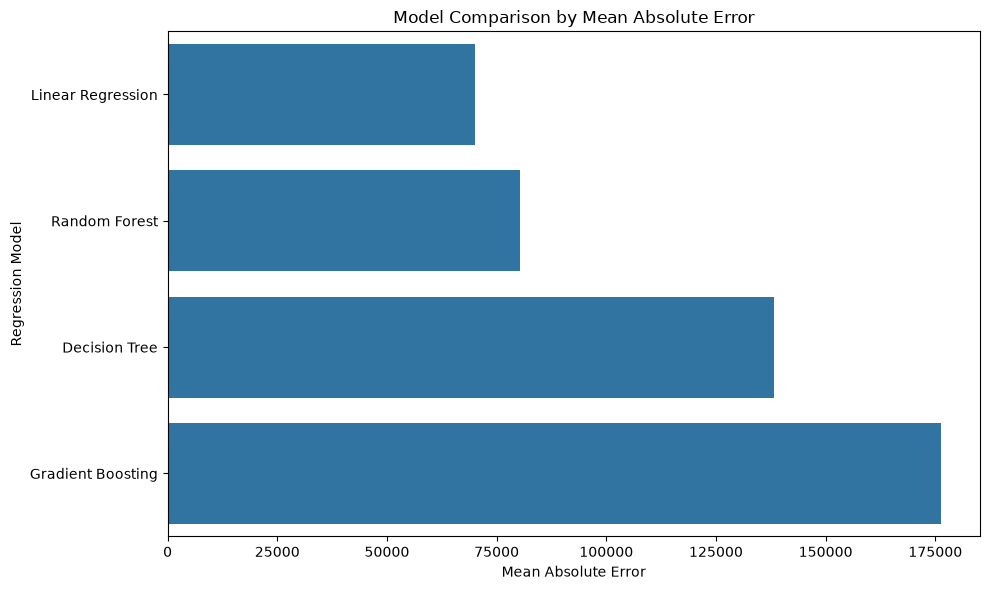

In [29]:
# Creating the MAE comparison chart

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=results_by_mae,
    x="mae",
    y="model",
)

plt.title(
    "Model Comparison by Mean Absolute Error"
)
plt.xlabel(
    "Mean Absolute Error"
)
plt.ylabel(
    "Regression Model"
)
plt.tight_layout()

plt.savefig(
    images_path / "model_comparison_mae.png",
    bbox_inches="tight",
)

plt.show()

### MAE Comparison Interpretation

The Mean Absolute Error (MAE) comparison shows the average difference between the actual weekly sales and the predicted weekly sales for each regression model. Lower MAE values indicate better predictive performance because the model makes smaller prediction errors on average.

The comparison shows that **Linear Regression** achieved the **lowest MAE (69,989.55)**, indicating that it produced the most accurate predictions among all evaluated models. This suggests that the relationship between the selected features and weekly sales is largely linear, allowing the model to generalize well to unseen data.

**Random Forest** ranked second with an MAE of **80,398.99**. Although it performed well and captured more complex relationships in the data, it produced slightly larger prediction errors than Linear Regression.

The **Decision Tree** model recorded an MAE of **138,187.23**, which is substantially higher than both Linear Regression and Random Forest. This indicates that the model was less accurate when predicting weekly sales on the test dataset.

**Gradient Boosting** produced the highest MAE (**176,368.38**), making it the least accurate model based on this evaluation metric. Its larger prediction errors suggest that it did not generalize as effectively to the chronological test data.

Overall, the MAE comparison demonstrates that **Linear Regression is currently the strongest model**, as it consistently produced the smallest average prediction error. Random Forest is a competitive alternative, while Decision Tree and Gradient Boosting were less accurate for this dataset.

## Model Comparison by RMSE

Root Mean Squared Error gives additional weight to large prediction errors.

A lower RMSE indicates better performance and fewer severe prediction mistakes.

In [30]:
# Comparing models by RMSE

results_by_rmse = (
    formatted_results_df
    .sort_values(
        by="rmse",
        ascending=True,
    )
    .reset_index(drop=True)
)

results_by_rmse

,model,mae,rmse,r2_score
0,Linear Regression,69989.55,101451.25,0.9638
1,Random Forest,80398.99,116209.23,0.9526
2,Decision Tree,138187.23,197760.41,0.8626
3,Gradient Boosting,176368.38,201032.57,0.8581


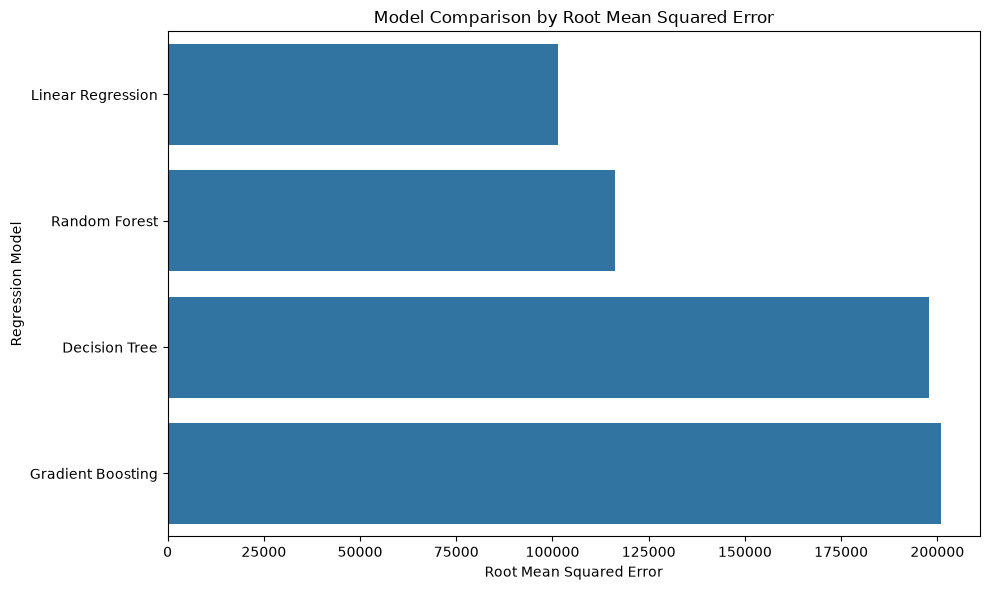

In [31]:
# Creating the RMSE comparison chart

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=results_by_rmse,
    x="rmse",
    y="model",
)

plt.title(
    "Model Comparison by Root Mean Squared Error"
)
plt.xlabel(
    "Root Mean Squared Error"
)
plt.ylabel(
    "Regression Model"
)
plt.tight_layout()

plt.savefig(
    images_path / "model_comparison_rmse.png",
    bbox_inches="tight",
)

plt.show()

### RMSE Comparison Interpretation

Root Mean Squared Error (RMSE) measures the average prediction error while giving greater weight to larger prediction mistakes. A lower RMSE indicates that a model makes more accurate predictions and avoids large errors.

The comparison shows that **Linear Regression** achieved the **lowest RMSE (101,451.25)**, indicating that it produced the smallest overall prediction errors. This suggests that the model generalized well to the chronological test data and made fewer severe prediction mistakes than the other models.

**Random Forest** achieved the second-lowest RMSE (**116,209.23**). Although it performed well and remained competitive, it still produced larger prediction errors than Linear Regression.

The **Decision Tree** model recorded an RMSE of **197,760.41**, indicating considerably larger prediction errors. This suggests that the model struggled to generalize effectively to unseen data and may have overfitted the training data.

**Gradient Boosting** produced the highest RMSE (**201,032.57**), making it the weakest-performing model according to this metric. Its larger RMSE indicates that it generated the greatest prediction errors, particularly for observations with extreme weekly sales values.

The RMSE comparison agrees with the earlier MAE comparison. Both evaluation metrics ranked **Linear Regression** as the best-performing model, followed by **Random Forest**, while **Decision Tree** and **Gradient Boosting** showed substantially poorer performance.

### Conclusion

Based on the RMSE evaluation, **Linear Regression** is the most accurate model because it achieved the lowest Root Mean Squared Error, indicating the fewest large prediction errors. The agreement between both the **MAE** and **RMSE** metrics provides stronger evidence that Linear Regression is the most reliable model for predicting Walmart weekly sales.

## Compare models by R² score

### Model Comparison by R² Score

R² measures how much of the variation in weekly sales is explained by the model.

A higher R² score indicates stronger predictive performance.

In [32]:
# Comparing models by R² score

results_by_r2 = (
    formatted_results_df
    .sort_values(
        by="r2_score",
        ascending=False,
    )
    .reset_index(drop=True)
)

results_by_r2

,model,mae,rmse,r2_score
0,Linear Regression,69989.55,101451.25,0.9638
1,Random Forest,80398.99,116209.23,0.9526
2,Decision Tree,138187.23,197760.41,0.8626
3,Gradient Boosting,176368.38,201032.57,0.8581


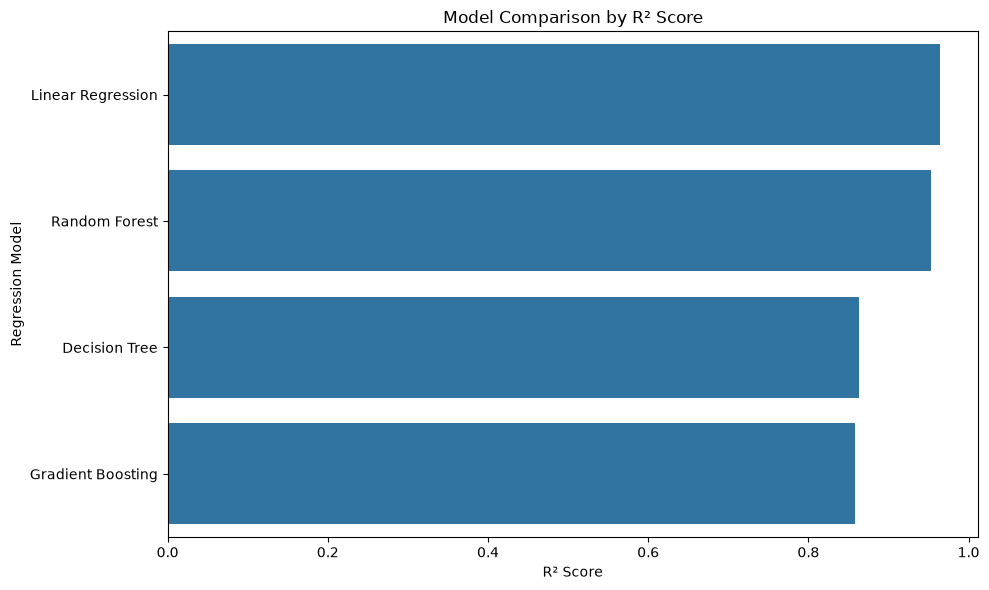

In [33]:
# Creating the R² comparison chart

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=results_by_r2,
    x="r2_score",
    y="model",
)

plt.title(
    "Model Comparison by R² Score"
)
plt.xlabel(
    "R² Score"
)
plt.ylabel(
    "Regression Model"
)
plt.tight_layout()

plt.savefig(
    images_path / "model_comparison_r2.png",
    bbox_inches="tight",
)

plt.show()

### R² Score Comparison Interpretation

The R² score measures how much of the variation in the target variable (weekly sales) is explained by the regression model. A higher R² value indicates that the model captures more of the relationship between the input features and weekly sales, resulting in stronger predictive performance.

The comparison shows that **Linear Regression** achieved the highest **R² score (0.9638)**. This means that the model explains approximately **96.38%** of the variation in weekly sales within the chronological test dataset, demonstrating an excellent fit and strong predictive capability.

**Random Forest** achieved the second-highest **R² score (0.9526)**. Although it also explained a large proportion of the variation in weekly sales, its performance was slightly lower than Linear Regression, making it a competitive but less accurate alternative.

The **Decision Tree** model recorded an **R² score of 0.8626**, indicating that it explained approximately **86.26%** of the variation in weekly sales. This lower value suggests that the model was less effective at capturing the underlying relationships in the data.

**Gradient Boosting** achieved the lowest **R² score (0.8581)**, explaining approximately **85.81%** of the variation in weekly sales. This indicates weaker predictive performance compared with the other regression models.

The R² comparison is consistent with the earlier **MAE** and **RMSE** evaluations. All three metrics ranked **Linear Regression** as the best-performing model, followed by **Random Forest**, while **Decision Tree** and **Gradient Boosting** produced noticeably weaker results.

### Conclusion

Based on the R² evaluation, **Linear Regression** demonstrated the strongest predictive performance by explaining the largest proportion of the variation in weekly sales. Together with its lowest **MAE** and **RMSE**, this provides strong evidence that Linear Regression is the most suitable model for predicting Walmart weekly sales in this project.

## Combined Model Ranking

### Rank models using all three metrics

Selecting a model using MAE alone is not enough. We will rank the models using:

- MAE rank
- RMSE rank
- R² rank.

In [34]:
# Ranking models using all three metrics

comparison_df = formatted_results_df.copy()

comparison_df["mae_rank"] = (
    comparison_df["mae"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

comparison_df["rmse_rank"] = (
    comparison_df["rmse"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

comparison_df["r2_rank"] = (
    comparison_df["r2_score"]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

comparison_df["overall_rank_score"] = (
    comparison_df["mae_rank"]
    + comparison_df["rmse_rank"]
    + comparison_df["r2_rank"]
)

comparison_df

,model,mae,rmse,r2_score,mae_rank,rmse_rank,r2_rank,overall_rank_score
0,Linear Regression,69989.55,101451.25,0.9638,1,1,1,3
1,Decision Tree,138187.23,197760.41,0.8626,3,3,3,9
2,Random Forest,80398.99,116209.23,0.9526,2,2,2,6
3,Gradient Boosting,176368.38,201032.57,0.8581,4,4,4,12


### Overall Model Ranking Interpretation

Evaluating a regression model using only one performance metric can sometimes lead to misleading conclusions. Therefore, the regression models were ranked using all three evaluation metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

For MAE and RMSE, the model with the **lowest error** received the highest rank (Rank 1). For the R² score, the model with the **highest value** received Rank 1. The three ranks were then added together to produce an overall ranking score.

The results show that **Linear Regression** achieved **Rank 1** across all three evaluation metrics, producing the lowest MAE, the lowest RMSE, and the highest R² score. Its overall ranking score of **3** is the lowest possible score, demonstrating the most consistent and accurate predictive performance among all the evaluated models.

**Random Forest** ranked second in every evaluation metric, resulting in an overall ranking score of **6**. Although it produced strong predictions, its performance was consistently slightly lower than Linear Regression.

**Decision Tree** ranked third across all evaluation metrics, giving it an overall ranking score of **9**. This indicates that it produced larger prediction errors and explained less variation in weekly sales than the two best-performing models.

**Gradient Boosting** ranked fourth for MAE, RMSE, and R², resulting in the highest overall ranking score of **12**. This suggests that it was the weakest-performing regression model for this dataset.

### Final Model Selection

The combined ranking confirms the conclusions reached from the individual MAE, RMSE, and R² comparisons. Since **Linear Regression** consistently achieved the best performance across all evaluation metrics, it was selected as the final regression model for predicting Walmart weekly sales.

Using multiple evaluation metrics provides greater confidence that the selected model is both accurate and reliable rather than performing well on only a single metric.

In [35]:
# Sorting by the overall ranking

final_ranking_df = (
    comparison_df
    .sort_values(
        by=[
            "overall_rank_score",
            "mae",
            "rmse",
            "r2_score",
        ],
        ascending=[
            True,
            True,
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

final_ranking_df.insert(
    0,
    "final_position",
    range(
        1,
        len(final_ranking_df) + 1,
    ),
)

final_ranking_df

,final_position,model,mae,rmse,r2_score,mae_rank,rmse_rank,r2_rank,overall_rank_score
0,1,Linear Regression,69989.55,101451.25,0.9638,1,1,1,3
1,2,Random Forest,80398.99,116209.23,0.9526,2,2,2,6
2,3,Decision Tree,138187.23,197760.41,0.8626,3,3,3,9
3,4,Gradient Boosting,176368.38,201032.57,0.8581,4,4,4,12


In [36]:
# Selecting the final best model

best_model_name = (
    final_ranking_df
    .iloc[0]["model"]
)

best_model_results = (
    final_ranking_df
    .iloc[0]
)

print(
    "Final best model:",
    best_model_name,
)

print(
    "MAE:",
    best_model_results["mae"],
)

print(
    "RMSE:",
    best_model_results["rmse"],
)

print(
    "R² score:",
    best_model_results["r2_score"],
)

print(
    "Overall rank score:",
    best_model_results["overall_rank_score"],
)

Final best model: Linear Regression
MAE: 69989.55
RMSE: 101451.25
R² score: 0.9638
Overall rank score: 3


## Final Model Selection

Based on the model comparison results, **Linear Regression** was selected as the final prediction model.

It achieved:

- The lowest Mean Absolute Error (MAE)
- The lowest Root Mean Squared Error (RMSE)
- The highest R² score
- The best overall combined ranking

The model produced a **Mean Absolute Error (MAE) of approximately 69,989.55**, meaning that its weekly sales predictions differed from the actual values by about **69,990 sales units on average**.

Its **Root Mean Squared Error (RMSE) of approximately 101,451.25** indicates that it also produced the smallest large prediction errors among all evaluated models.

The **R² score of 0.9638** shows that Linear Regression explained approximately **96.38% of the variation in weekly sales**, demonstrating excellent predictive performance on the chronological test dataset.

Although **Random Forest** also performed well and ranked second across all evaluation metrics, Linear Regression consistently achieved better results for MAE, RMSE, and R² score.

Therefore, **Linear Regression was selected as the final model** because it delivered the most accurate predictions, the strongest overall performance, and the best combined ranking across all evaluation metrics.

The selected model will now be saved (serialized) and used for prediction, deployment, and future inference.

## Load and Save the Final Model

In [37]:
# Loading all trained models

with open(
    trained_models_path,
    "rb",
) as file:
    trained_models = pickle.load(file)

print(
    "Available trained models:",
    list(trained_models.keys()),
)

Available trained models: ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


In [38]:
# Retrieving the selected model

if best_model_name not in trained_models:
    raise KeyError(
        f"{best_model_name} was not found "
        "inside the trained-model dictionary."
    )

final_best_model = trained_models[
    best_model_name
]

print(
    "Selected model object:",
    final_best_model,
)

Selected model object: LinearRegression()


In [39]:
# Saving the final model using pickle

final_model_path = (
    models_path
    / "final_walmart_sales_model.pkl"
)

with open(
    final_model_path,
    "wb",
) as file:
    pickle.dump(
        final_best_model,
        file,
    )

print(
    "Final model saved to:",
    final_model_path,
)

Final model saved to: c:\Users\Udoch\walmart-sales-regression\models\final_walmart_sales_model.pkl


In [40]:
# Confirming that the model was saved

print(
    "File exists:",
    final_model_path.exists(),
)

print(
    "File size in bytes:",
    final_model_path.stat().st_size,
)

File exists: True
File size in bytes: 3356


In [41]:
# Test loading the saved model

with open(
    final_model_path,
    "rb",
) as file:
    loaded_final_model = pickle.load(file)

print(
    "Loaded model:",
    loaded_final_model,
)

print(
    "Model class:",
    type(loaded_final_model).__name__,
)

Loaded model: LinearRegression()
Model class: LinearRegression


It is important to confirm that the model file is not corrupted.

In [42]:
# Saving the complete ranking table

ranking_path = (
    prepared_data_path
    / "final_model_ranking.csv"
)

final_ranking_df.to_csv(
    ranking_path,
    index=False,
)

print(
    "Final ranking saved to:",
    ranking_path,
)

Final ranking saved to: c:\Users\Udoch\walmart-sales-regression\data\prepared\final_model_ranking.csv


In [43]:
# Saving a final-model summary

best_model_summary_df = pd.DataFrame(
    {
        "selected_model": [
            best_model_name
        ],
        "mae": [
            best_model_results["mae"]
        ],
        "rmse": [
            best_model_results["rmse"]
        ],
        "r2_score": [
            best_model_results["r2_score"]
        ],
        "overall_rank_score": [
            best_model_results[
                "overall_rank_score"
            ]
        ],
    }
)

best_model_summary_path = (
    prepared_data_path
    / "best_model_summary.csv"
)

best_model_summary_df.to_csv(
    best_model_summary_path,
    index=False,
)

best_model_summary_df

,selected_model,mae,rmse,r2_score,overall_rank_score
0,Linear Regression,69989.55,101451.25,0.9638,3


In [44]:
# Confirming all generated files

generated_files = [
    final_model_path,
    ranking_path,
    best_model_summary_path,
    images_path / "model_comparison_mae.png",
    images_path / "model_comparison_rmse.png",
    images_path / "model_comparison_r2.png",
]

for file_path in generated_files:
    print(
        file_path.name,
        "->",
        file_path.exists(),
    )

final_walmart_sales_model.pkl -> True
final_model_ranking.csv -> True
best_model_summary.csv -> True
model_comparison_mae.png -> True
model_comparison_rmse.png -> True
model_comparison_r2.png -> True


## Phase 9 Summary

The model-comparison and best-model-selection phase was completed successfully.

The following tasks were completed:

- Loaded the Phase 8 model evaluation results.
- Compared Linear Regression, Decision Tree, Random Forest, and Gradient Boosting.
- Evaluated every model using MAE, RMSE, and R².
- Created separate visual comparisons for each evaluation metric.
- Ranked the models using all three metrics.
- Selected Linear Regression as the final best model.
- Saved the final trained model using Python's `pickle` module.
- Saved the final model-ranking and model-summary tables.
- Confirmed that the serialized model could be loaded successfully.

Linear Regression was selected because it achieved the lowest MAE, lowest RMSE, and highest R² score on the chronological test data.

The project is now ready for the next phase, which will focus on detailed model evaluation, residual analysis, and validation of the selected model.